Kjør kun for å oppdatere til ny versjon av HLS4ML direkte fra GitHub-repo.
´conda env update -f environment.yml´

In [ ]:
!conda env update -f environment.yml

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: - 

In [25]:
# Check available backends for vitisunified
import hls4ml
hls4ml.backends.backend.get_available_backends()

['vivado',
 'vivadoaccelerator',
 'vitis',
 'vitisunified',
 'quartus',
 'catapult',
 'symbolicexpression',
 'oneapi',
 'libero']

# Example of creating a model and importing into a Vivado-project
Based on [hls4ml-tutorial part 3](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/part3_compression.ipynb) and [Tanawin1701d/vitisUnifiedTutorial](https://github.com/Tanawin1701d/vitisUnifiedTutorial).

To store multiple revisions, the following parameters are used throughout. Make sure to update them if you want to keep multiple revisions.

Make sure to start this from conda environment with Vitis loaded to path.
´conda activate hls4ml-kv260-testenv´

In [ ]:
import os
model_to_test = 'testmodel'
model_revision = 1
hls4ml_revision = 'VitisUnifiedKV260_1'

base_dir = os.path.abspath(model_to_test)
model_dir = os.path.join(base_dir, str(model_revision))
os.makedirs(model_dir, exist_ok=True)

description = """
# Model Configuration

En simpel model for å teste A til Å med Vitis Unified på KV260.

- **Model Revision**: {model_revision}
- **HLS4ML Revision**: {hls4ml_revision}
- **Backend**: Vitis Unified [[https://github.com/fastmachinelearning/hls4ml/pull/1376]]
- **Target Device**: KV260 (xck26-sfvc784-2LV-c)
- **Dataset**: HLS4ML LHC Jets
"""
output_dir = os.path.join(model_dir, f"hls4ml_prj_{hls4ml_revision}")
os.makedirs(output_dir, exist_ok=True)
with open(os.path.join(output_dir, "description.md"), "w", encoding="utf-8") as f:
    f.write(description)

In [18]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)
import os

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

Load dataset and save data. If the data is already saved to disk, load the local cache.

In [19]:
# Use absolute paths for data files
x_train_val_path = os.path.join(base_dir, "x_train_val.npy")
x_test_path = os.path.join(base_dir, "x_test.npy")
y_train_val_path = os.path.join(base_dir, "y_train_val.npy")
y_test_path = os.path.join(base_dir, "y_test.npy")
classes_path = os.path.join(base_dir, "classes.npy")

if not os.path.exists(x_train_val_path):
    data = fetch_openml('hls4ml_lhc_jets_hlf')
    x, y = data['data'], data['target']

    le = LabelEncoder()
    y = le.fit_transform(y)
    y = to_categorical(y, 5)
    x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    x_train_val = scaler.fit_transform(x_train_val)
    x_test = scaler.transform(x_test)

    np.save(x_train_val_path, x_train_val)
    np.save(x_test_path, x_test)
    np.save(y_train_val_path, y_train_val)
    np.save(y_test_path, y_test)
    np.save(classes_path, le.classes_)
else:
    x_train_val = np.load(x_train_val_path)
    x_test = np.load(x_test_path)
    y_train_val = np.load(y_train_val_path)
    y_test = np.load(y_test_path)
    classes = np.load(classes_path, allow_pickle=True)


Load existing model, or create and train a new

In [20]:
load_existing_model = True

keras_model_path = os.path.join(model_dir, "KERAS_model.h5")

if load_existing_model:
    from tensorflow.keras.models import load_model
    model = load_model(keras_model_path)
else:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Activation, BatchNormalization
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.regularizers import l1
    from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
    from tensorflow_model_optimization.sparsity.keras import strip_pruning
    from callbacks import all_callbacks

    model = Sequential()
    model.add(Dense(64, input_shape=(16,), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
    model.add(Activation(activation='relu', name='relu1'))
    model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
    model.add(Activation(activation='relu', name='relu2'))
    model.add(Dense(32, name='fc3', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
    model.add(Activation(activation='relu', name='relu3'))
    model.add(Dense(5, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
    model.add(Activation(activation='softmax', name='softmax'))

    pruning_params = {"pruning_schedule": pruning_schedule.ConstantSparsity(0.75, begin_step=2000, frequency=100)}
    model = prune.prune_low_magnitude(model, **pruning_params) 

    adam = Adam(lr=0.0001)
    model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])
    callbacks = all_callbacks(
        stop_patience=1000,
        lr_factor=0.5,
        lr_patience=10,
        lr_epsilon=0.000001,
        lr_cooldown=2,
        lr_minimum=0.0000001,
        outputDir=model_dir,
    )
    callbacks.callbacks.append(pruning_callbacks.UpdatePruningStep())
    model.fit(
        x_train_val,
        y_train_val,
        batch_size=1024,
        epochs=10,
        validation_split=0.25,
        shuffle=True,
        callbacks=callbacks.callbacks,
    )
    # Save the model again but with the pruning 'stripped' to use the regular layer types
    model = strip_pruning(model)
    model.save(keras_model_path)


In [ ]:
from contextlib import redirect_stdout

# Save the model summary to a text file
with open(os.path.join(model_dir, "summary.txt"), "w", encoding="utf-8") as f:
    with redirect_stdout(f):
        model.summary()

# Convert and synthesize with HLS4ML
Uses KV260 (xck26-sfvc784-2LV-c). You need to set the xpfm-path manually (it should be set based on env-path in source code?)

In [ ]:
xPFM_PATH = '/usr/lib/AMD/2025.2/Vitis/base_platforms/xilinx_kv260_base_202520_1/xilinx_kv260_base_202520_1.xpfm'

In [7]:
import hls4ml

hls_config = hls4ml.utils.config_from_keras_model(model, granularity='name')
print(hls_config)

{'Model': {'Precision': {'default': 'fixed<16,6>'}, 'ReuseFactor': 1, 'Strategy': 'Latency', 'BramFactor': 1000000000, 'TraceOutput': False}}


In [ ]:
hls_model = hls4ml.converters.convert_from_keras_model(
    model, 
    hls_config  = hls_config, 
    backend     = 'vitisunified', 
    #project_name=f'{model_to_test}_{model_revision}_hls4ml_prj_{hls4ml_revision}', # Bug ved feil bruk av denne når axi_master.cpp skal hentes i ´vitis_unified_writer´
    output_dir  = output_dir, 
    board       = 'kv260',
    part        = 'xck26-sfvc784-2LV-c',
    clock_period= '5ns',
    #in_stream_buf_size = 128,
    #out_stream_buf_size = 128,
    #xpfmPath   =   xPFM_PATH,
    io_type     = "io_stream",
    strategy    = "latency",
    granularity = "name",
    amt_query   = 10,
    axi_mode    = "axim",
)
hls_model.compile()
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True,to_file=os.path.join(output_dir, "model-plot.png"))


In [9]:
print(hls_model.config.config)
hls_model.config.get_output_dir()
hls_model.config.backend.writer.get_vitis_linker_dir(hls_model)

{'OutputDir': '/home/ncgadmin/Bachelor/ATLAS-ML-for-FPGA/hls4ml-dev-testenv/testmodel/1/hls4ml_prj_VitisUnifiedKV260_1', 'ProjectName': 'myproject', 'Backend': 'VitisUnified', 'Version': '1.0.0', 'Part': 'xck26-sfvc784-2LV-c', 'ClockPeriod': '5ns', 'ClockUncertainty': '12.5%', 'IOType': 'io_stream', 'HLSConfig': {'Model': {'Precision': {'default': 'fixed<16,6>'}, 'ReuseFactor': 1, 'Strategy': 'Latency', 'BramFactor': 1000000000, 'TraceOutput': False, 'BitExact': None}}, 'WriterConfig': {'Namespace': None, 'WriteWeightsTxt': True, 'WriteTar': False, 'TBOutputStream': 'both', 'WriteEmulationConstants': False}, 'VitisUnifiedConfig': {'Board': 'kv260', 'axi_mode': 'axi_master', 'in_stream_buf_size': 128, 'out_stream_buf_size': 128, 'Driver': 'python', 'InputDtype': 'float', 'OutputDtype': 'float'}, 'KerasModel': <keras.src.engine.sequential.Sequential object at 0x7bb647cff850>, 'InputData': None, 'OutputPredictions': None, 'InputShapes': {'fc1_input': [16]}, 'OutputShapes': {'layer13_out':

'/home/ncgadmin/Bachelor/ATLAS-ML-for-FPGA/hls4ml-dev-testenv/testmodel/1/hls4ml_prj_VitisUnifiedKV260_1/vitis_workspace/system_link'

Test the HLS-model if it actually works

In [13]:
hls_model.predict(np.ascontiguousarray(x_test))

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

Implementation details
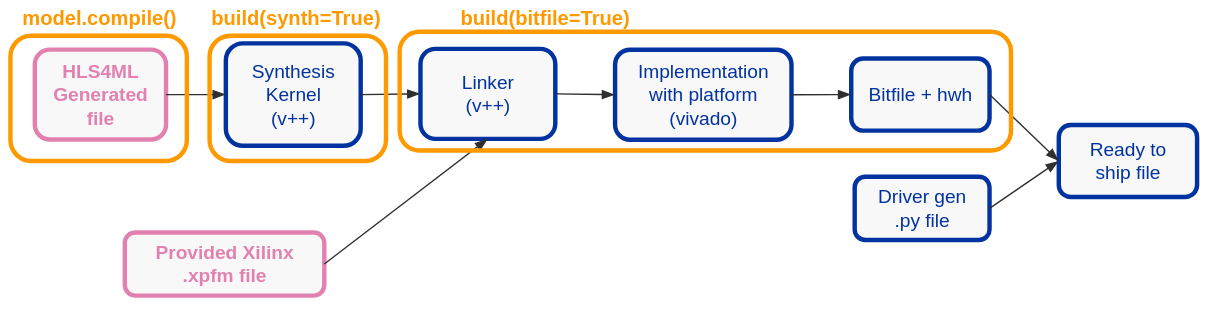
[Origin and more information](https://github.com/fastmachinelearning/hls4ml/pull/1376)

In [ ]:
#hls_model.build(csim=False)

# Create IP-blokk ()
hls_model.build(synth=True, 
                bitfile=True) 

# 1.
# Får error med csynth, "ikke spesifisert part"
# v++ -c --mode hls --config testmodel/1/hls4ml_prj_VitisUnifiedKV260_1/hls_kernel_config.cfg --work_dir vitis_unified_project
# fungerer når jeg kjører i shell selv, hmmm. Må være noe feil med kjøring av kommando
# cwd settes til en subdirectory som da ikke gir mening ift. config-fil
# FIx: Måtte bruke absolutt paths. Fikse en warning for dette?

# 2. 
# Får error v++ med feil .xPFM-plattformfil fra link_system.sh 
# >>>> v++ -l -t hw --platform /usr/lib/AMD/2025.2/Vitis/base_platforms/xilinx_zcu102_base_202320_1/xilinx_zcu102_base_202320_1.xpfm ../myproject/vitis_unified_project/myproject_axi_master.xo --config link_system.cfg -o myproject.xclbin --save-temps
# Utfra model...config() får man VitisUnifiedConfig: zcu-greiene, så virker ikke som at config for part settes!

# 3.
# Får error xRT etter bitstream er laget
# cp: cannot stat '_x/link/vivado/vpl/prj/prj.gen/sources_1/bd/vitis_design/hw_handoff/vitis_design.hwh': No such file or directory
# Det er vel selve pakkingen av filene?


****** v++ v2025.2 (64-bit)
  **** SW Build 6295257 on 2025-11-13-01:29:13
  **** Start of session at: Thu Feb 26 20:36:54 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2025.2 6295257
INFO: [HLS 200-2005] Using work_dir /home/ncgadmin/Bachelor/ATLAS-ML-for-FPGA/hls4ml-dev-testenv/testmodel/1/hls4ml_prj_VitisUnifiedKV260_1/vitis_workspace/myproject/vitis_unified_project 
INFO: [HLS 200-2176] Writing Vitis IDE component file /home/ncgadmin/Bachelor/ATLAS-ML-for-FPGA/hls4ml-dev-testenv/testmodel/1/hls4ml_prj_VitisUnifiedKV260_1/vitis_workspace/myproject/vitis_unified_project/vitis-comp.json
INFO: [HLS 200-10] Creating and opening component '/home/ncgadmin/Bachelor/ATLAS-ML-for-FPGA/hls4ml-dev-testenv/testmodel/1/hls4ml_prj_VitisUnifiedKV260_1/vitis_workspace/myproject/vitis_unified_project'.
INFO: [HLS 200-1505] Using default flow_target 'vivado'
Resolution: For help on HLS

cp: cannot stat '_x/link/vivado/vpl/prj/prj.gen/sources_1/bd/vitis_design/hw_handoff/vitis_design.hwh': No such file or directory


In [10]:
hls4ml.report.read_vivado_report(output_dir)


Unable to read project data. Exiting.


# Run inference
Created a test notebook on the devkit

In [ ]:
model_pred = model.predict(x_test[:10])
hls4ml_pred = hls_model.predict(np.ascontiguousarray(x_test[:10]))

print(model_pred, '\n', hls4ml_pred, '\n', y_test[:10])


1/1 [==============================] - 0s 17ms/step
[[4.89103138e-01 3.11882615e-01 2.85640620e-02 8.40992182e-02
  8.63509774e-02]
 [5.87134697e-02 6.95502758e-01 7.57647445e-03 1.46307394e-01
  9.18999612e-02]
 [1.31430954e-01 7.03679919e-02 7.93074787e-01 2.44480907e-03
  2.68137036e-03]
 [5.91954868e-03 5.84506290e-03 9.87439215e-01 4.96233930e-04
  3.00062384e-04]
 [1.89566612e-02 1.23409536e-02 9.68048632e-01 3.83851700e-04
  2.69849057e-04]
 [3.26372147e-01 6.64814562e-02 5.89625478e-01 4.62832104e-04
  1.70580987e-02]
 [3.50082397e-01 3.32172960e-01 1.11420296e-01 1.00588582e-01
  1.05735719e-01]
 [8.27375829e-01 8.46566036e-02 2.45485157e-02 4.02185172e-02
  2.32005157e-02]
 [8.03101286e-02 5.96599281e-01 9.39921010e-03 1.57033443e-01
  1.56657994e-01]
 [1.09348322e-04 5.11293591e-04 4.72725881e-03 9.90222812e-01
  4.42934874e-03]] 
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 